## Customer Churn Prediction

Customer Churn Prediction is a Machine Learning task that focuses on identifying customers who are likely to stop using a service. The goal is to analyze historical customer data and build a model that can predict churn in advance, allowing businesses to take preventive actions such as retention offers or improved customer support.

This prediction helps businesses reduce customer loss, improve satisfaction, and increase overall revenue.


### Getting Data From SQL Server

The dataset is stored in SQL Server and is retrieved directly using Python for further preprocessing and Machine Learning tasks. SQLAlchemy is used to establish the database connection and load the data into a Pandas DataFrame for analysis and model preparation.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine, text

In [4]:
# Creating database connection
engine = create_engine(
    "mssql+pyodbc://localhost\\SQLEXPRESS/db_Churn"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

conn = engine.connect()

In [5]:
# Checking all tables available in the db_Churn
tables = pd.read_sql("SELECT TABLE_NAME FROM INFORMATION_SCHEMA.TABLES", conn)
tables

,TABLE_NAME
0,stg_Churn
1,prod_Churn
2,vw_ChurnData
3,vw_JoinData


In [6]:
df_churn = pd.read_sql("SELECT * FROM vw_ChurnData", conn)
df_join = pd.read_sql("SELECT * FROM vw_JoinData", conn)

In [7]:
df_join.to_csv("new_joiners_data.csv", index=False)

Two tables are extracted from the SQL Server database into Pandas DataFrames:

- df_churn: This dataset will be use for training and testing the Machine Learning model. It contains historical customer data along with churn labels.
- df_new_joiners: This dataset contains newly joined customers and will be used to make predictions on which customers are likely to churn in the future.

### Data Preprocessing

* Detailed data analysis and initial preprocessing were already performed in SQL for database management and analytical purposes.
* In this phase, preprocessing is specifically focused on preparing the dataset for Machine Learning models.

For Machine Learning, data preprocessing involves transforming raw data into a clean, structured, and model-ready format so algorithms can learn effectively. Since ML models cannot efficiently work with incomplete, inconsistent, or non-numerical data, preprocessing helps improve model accuracy, performance, and reliability.

Key preprocessing tasks include:

* Handling missing values
* Encoding categorical variables
* Feature scaling and normalization
* Removing duplicates and outliers
* Feature selection
* Train-test splitting

This step ensures the dataset is optimized for training and evaluating Machine Learning models effectively.

In [10]:
df_churn.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,None,Yes,No,...,Credit Card,65.6,593.30,0.00,0.0,381.51,974.81,Stayed,Others,Others
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,None,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10.0,96.21,610.28,Stayed,Others,Others
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0.0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0.0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,None,Yes,No,...,Credit Card,83.9,267.40,0.00,0.0,22.14,289.54,Churned,Dissatisfaction,Network reliability


**1. Checking missing values & Dtypes**

In [12]:
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 6007 entries, 0 to 6006
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6007 non-null   str    
 1   Gender                       6007 non-null   str    
 2   Age                          6007 non-null   int64  
 3   Married                      6007 non-null   str    
 4   State                        6007 non-null   str    
 5   Number_of_Referrals          6007 non-null   int64  
 6   Tenure_in_Months             6007 non-null   int64  
 7   Value_Deal                   6007 non-null   str    
 8   Phone_Service                6007 non-null   str    
 9   Multiple_Lines               6007 non-null   str    
 10  Internet_Service             6007 non-null   str    
 11  Internet_Type                6007 non-null   str    
 12  Online_Security              6007 non-null   str    
 13  Online_Backup                

**2. Checking Duplicates**

In [14]:
df_churn.duplicated().sum()

0

In [15]:
df_churn['Customer_ID'].duplicated().sum()

0

**3. Checking Outliers & correlation**

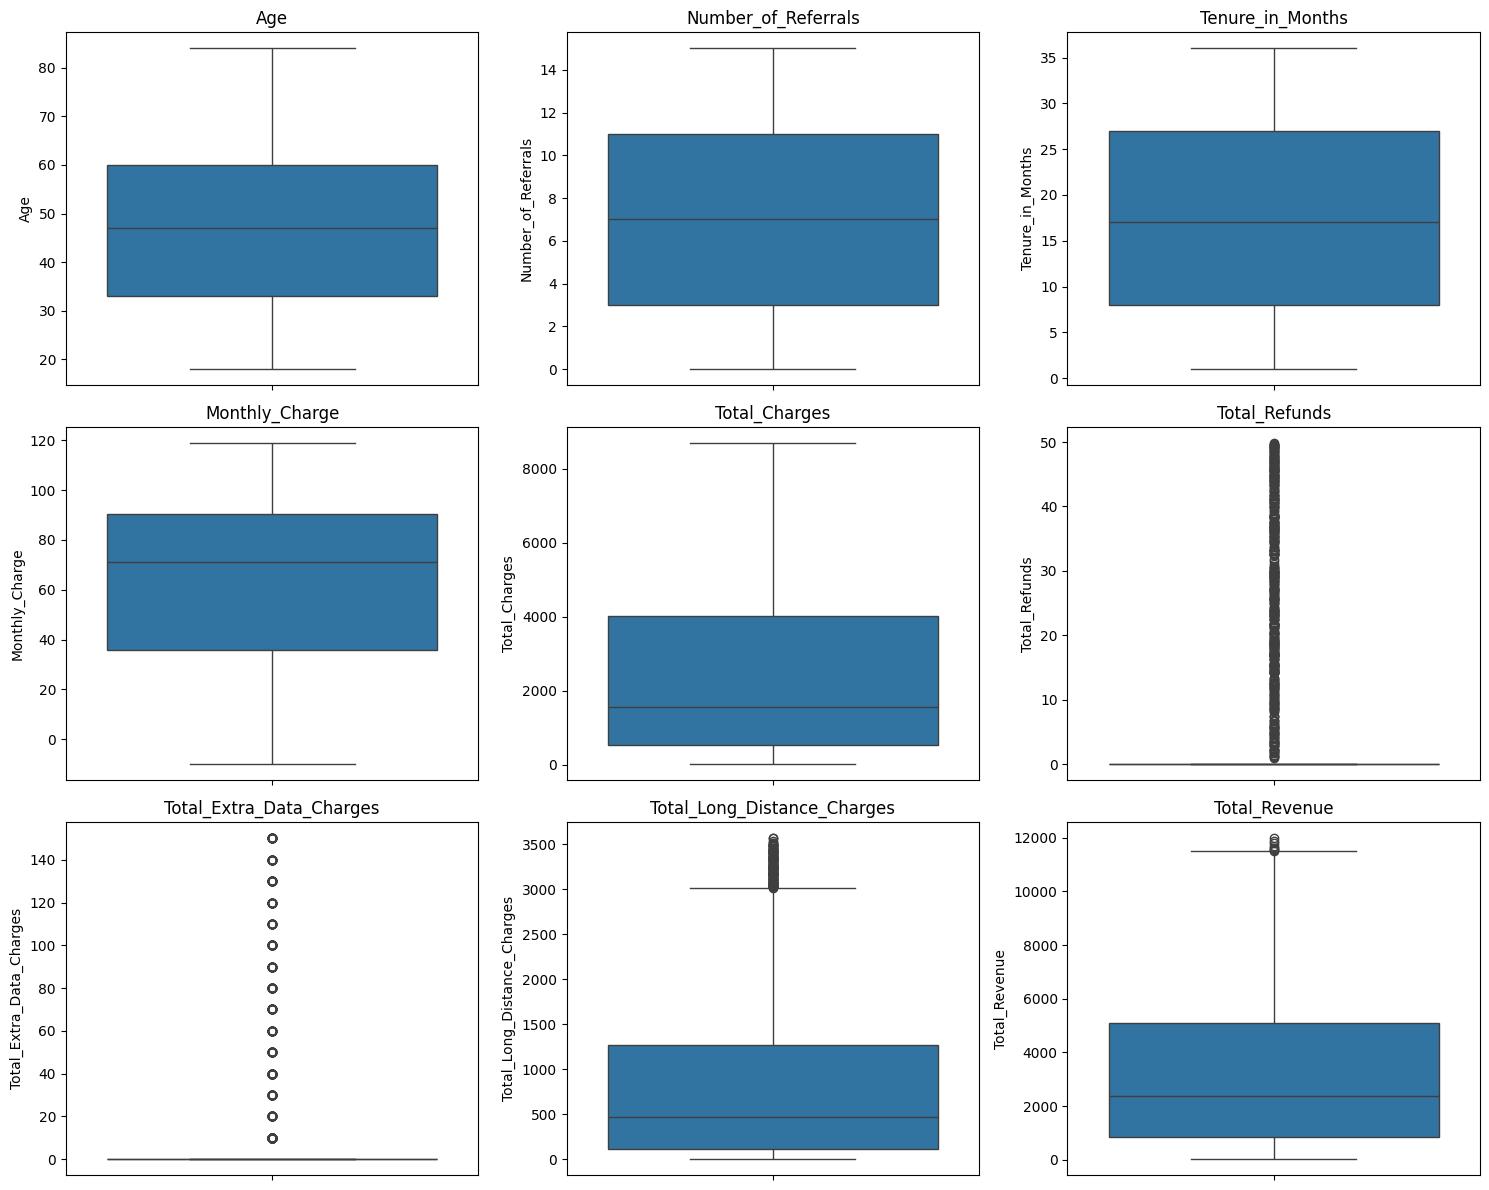

In [17]:
# Select numerical columns
num_cols = df_churn.select_dtypes(include='number').columns
n_cols = len(num_cols)

# Define grid size
cols = 3
rows = int(np.ceil(n_cols / cols)) # 9/3 = 3

plt.figure(figsize=(cols * 5, rows * 4))

for i, col in enumerate(num_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df_churn[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [18]:
corr = pd.concat([df_churn[num_cols], df_churn["Customer_Status"].map({"Stayed": 0, "Churned": 1})], axis=1).corr()

In [19]:
corr

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
Age,1.000000,-0.016397,0.149522,0.125732,0.047938,0.014267,0.026735,-0.006191,0.036402,0.108174
Number_of_Referrals,-0.016397,1.000000,-0.014297,-0.013672,-0.003073,0.015018,-0.003919,0.009926,0.000454,-0.006502
Tenure_in_Months,0.149522,-0.014297,1.000000,-0.006259,-0.005597,0.010538,0.023246,0.000232,-0.004197,0.007274
Monthly_Charge,0.125732,-0.013672,-0.006259,1.000000,0.619239,0.011646,0.117952,0.205873,0.554240,0.164216
Total_Charges,0.047938,-0.003073,-0.005597,0.619239,1.000000,0.023244,0.119024,0.585534,0.970130,-0.251783
Total_Refunds,0.014267,0.015018,0.010538,0.011646,0.023244,1.000000,0.019149,0.016602,0.020768,-0.045516
Total_Extra_Data_Charges,0.026735,-0.003919,0.023246,0.117952,0.119024,0.019149,1.000000,0.050786,0.118533,0.008098
Total_Long_Distance_Charges,-0.006191,0.009926,0.000232,0.205873,0.585534,0.016602,0.050786,1.000000,0.764554,-0.273525
Total_Revenue,0.036402,0.000454,-0.004197,0.554240,0.970130,0.020768,0.118533,0.764554,1.000000,-0.281553
Customer_Status,0.108174,-0.006502,0.007274,0.164216,-0.251783,-0.045516,0.008098,-0.273525,-0.281553,1.000000


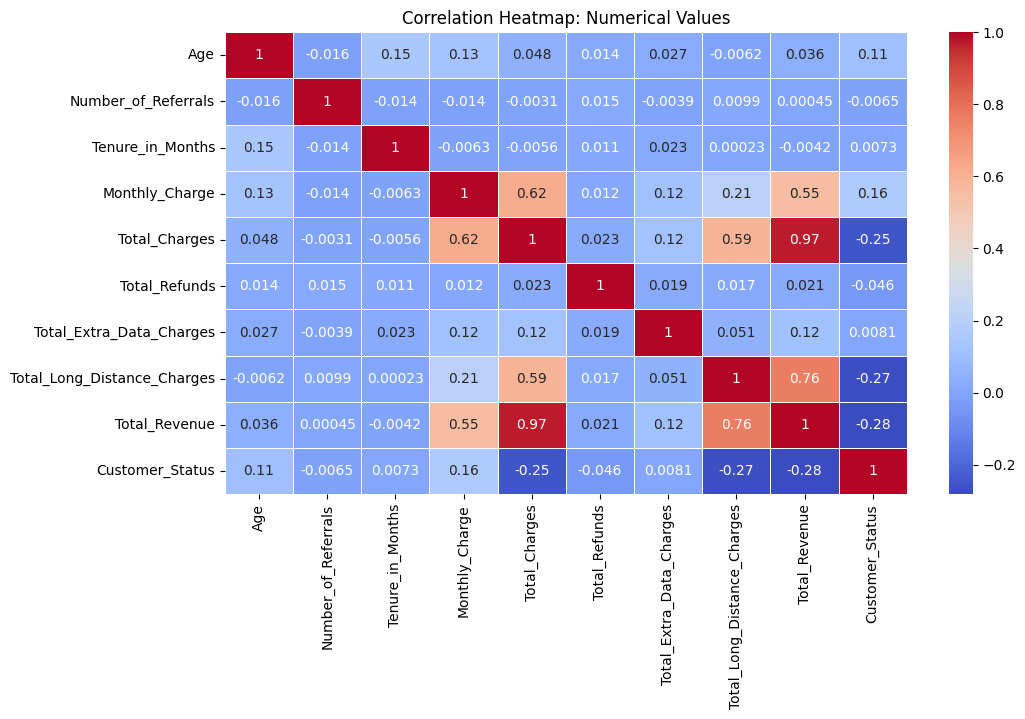

In [20]:
plt.figure(figsize=(11,6))
sns.heatmap(data=corr, annot = True, linewidths= 0.5, cmap='coolwarm')
plt.title("Correlation Heatmap: Numerical Values")
plt.show()

### Additional Exploratory Visualizations

The plots below extend the EDA with churn-driver breakdowns (demographics, account/contract behaviour, geography, and services used).

In [22]:
# Create Age_Group and Tenure_Group buckets
df_churn ['Age_Group'] = pd.cut(
    df_churn ['Age'], bins=[0, 20, 35, 50, 200],
    labels=['<20', '20-35', '35-50', '>50']
)

df_churn ['Tenure_Group'] = pd.cut(
    df_churn ['Tenure_in_Months'], bins=[-1, 6, 12, 18, 24, 1000],
    labels=['<6 Months', '6-12 Months', '12-18 Months', '18-24 Months', '>=24 Months']
)

# Helper: churn rate (%) per category

def churn_rate_by(col):
    return (
        df_churn .groupby(col, observed=True)['Customer_Status']
        .apply(lambda x: (x == 'Churned').mean() * 100)
        .sort_values(ascending=False)
    ) 

In [23]:
print("Churned:", (df_churn ['Customer_Status'] == 'Churned').sum())
print("Customers:", df_churn ['Customer_ID'].count())
print("Rows:", len(df_churn ))
print("Churn Rate:", (df_churn ['Customer_Status'] == 'Churned').sum() / df_churn ['Customer_ID'].count() * 100)

Churned: 1732
Customers: 6007
Rows: 6007
Churn Rate: 28.833028133843847


**Figure 1 — Demographic Insights**

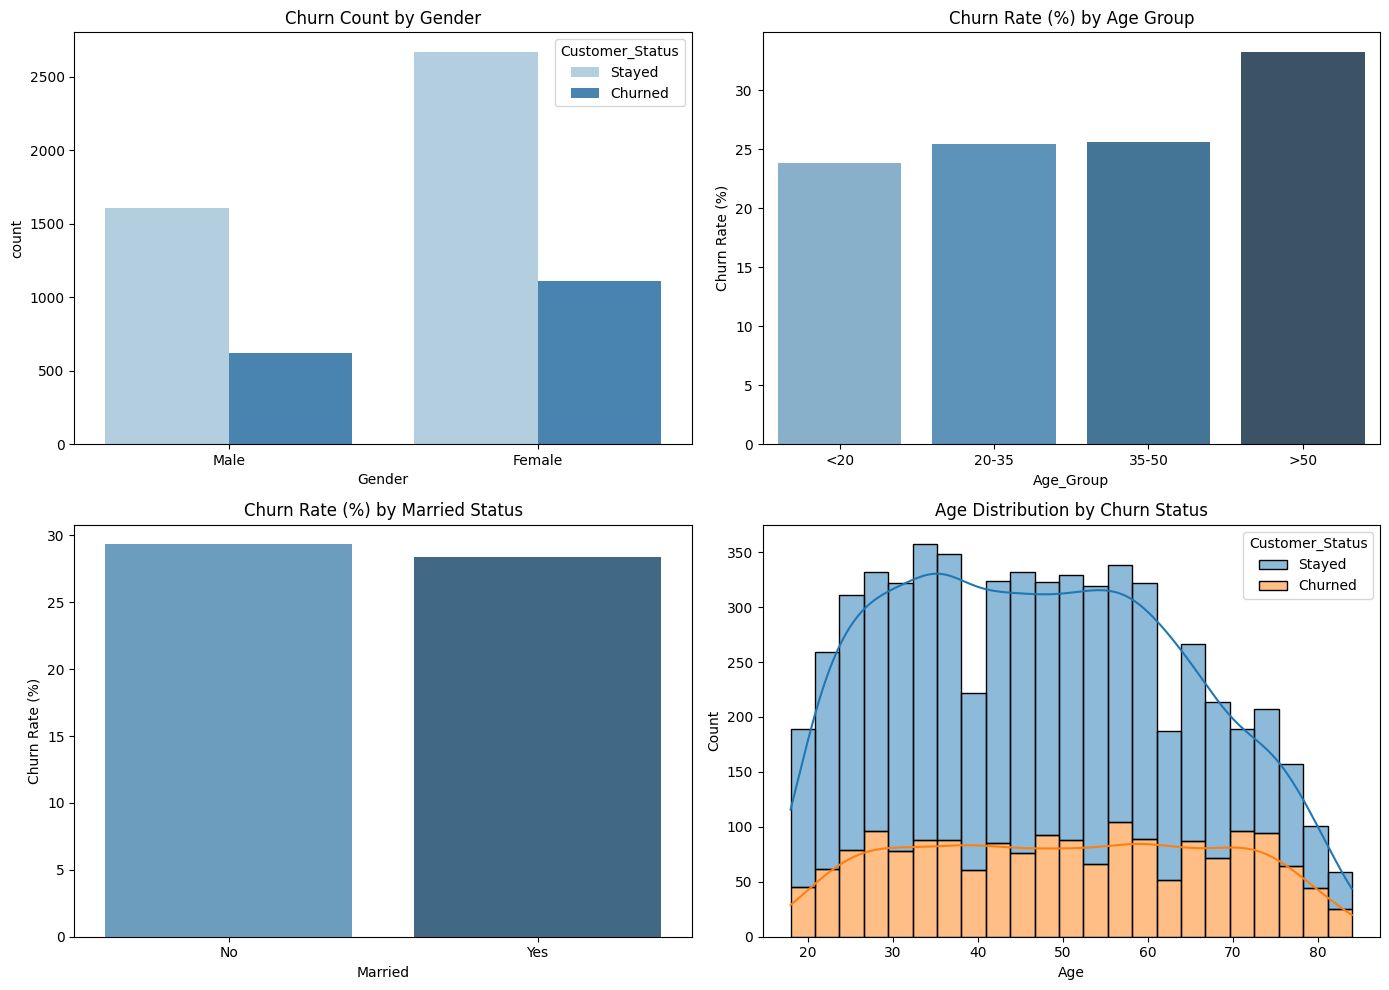

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gender vs Customer Status counts
sns.countplot(data=df_churn, x='Gender', hue='Customer_Status', ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Churn Count by Gender')

# 2. Churn rate by Age Group
cr = churn_rate_by('Age_Group').reindex(['<20', '20-35', '35-50', '>50'])
sns.barplot(x=cr.index, y=cr.values, ax=axes[0, 1], palette='Blues_d', hue=cr.index)
axes[0, 1].set_title('Churn Rate (%) by Age Group')
axes[0, 1].set_ylabel('Churn Rate (%)')

# 3. Churn rate by Marital Status
cr = churn_rate_by('Married')
sns.barplot(x=cr.index, y=cr.values, ax=axes[1, 0], palette='Blues_d', hue=cr.index)
axes[1, 0].set_title('Churn Rate (%) by Married Status')
axes[1, 0].set_ylabel('Churn Rate (%)')

# 4. Age distribution split by churn status
sns.histplot(data=df_churn, x='Age', hue='Customer_Status', kde=True, ax=axes[1, 1], multiple='stack')
axes[1, 1].set_title('Age Distribution by Churn Status')

plt.tight_layout()
plt.show()

**Figure 2 — Account & Contract Insights**

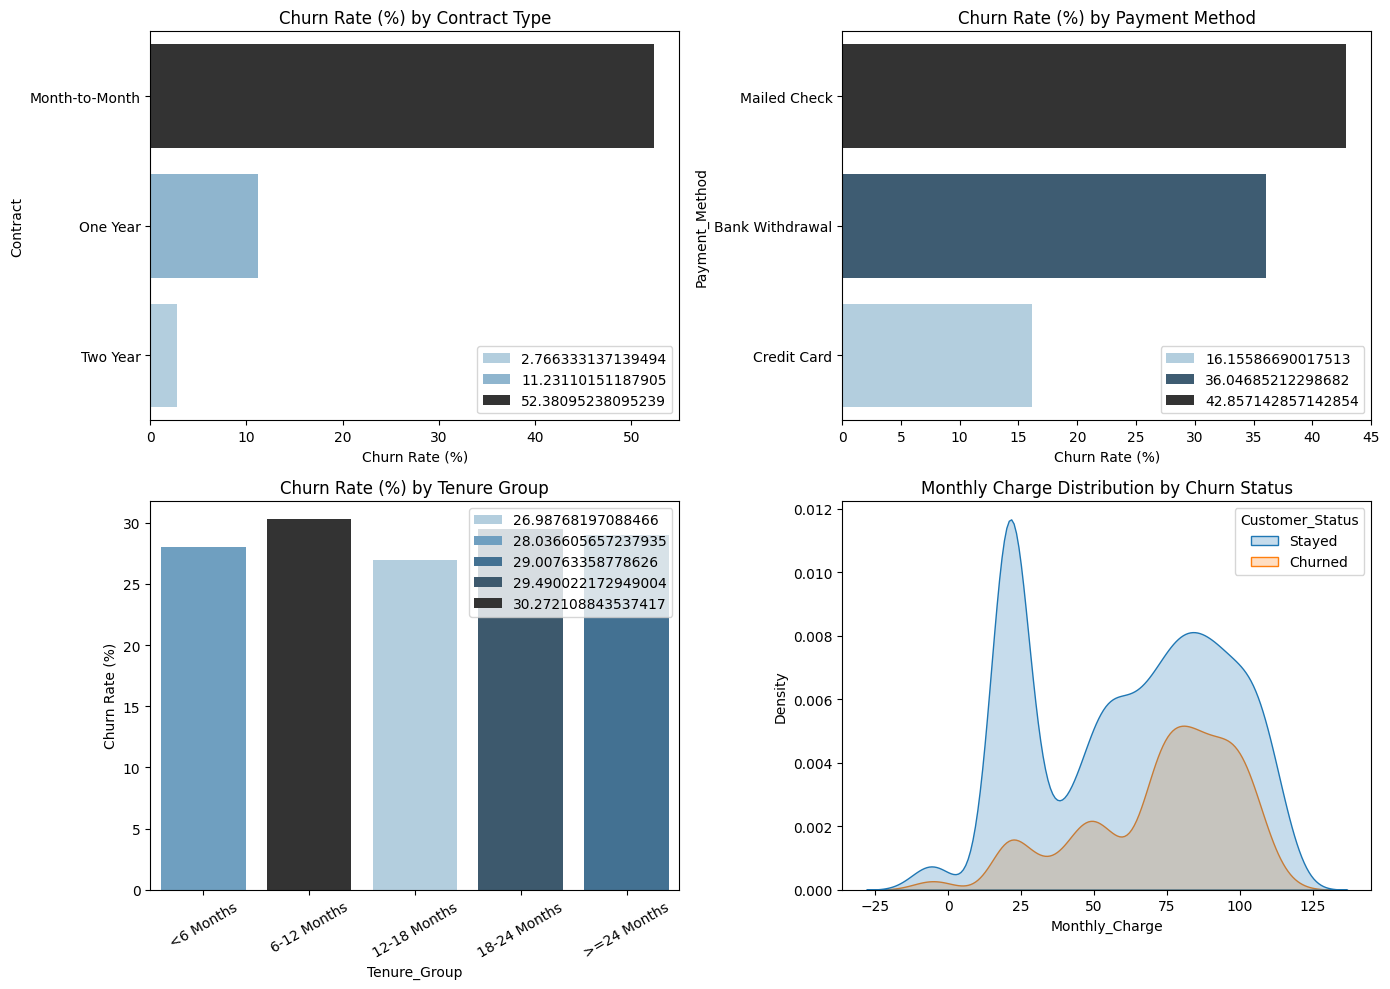

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5. Churn rate by Contract
cr = churn_rate_by('Contract')
sns.barplot(x=cr.values, y=cr.index, ax=axes[0, 0], palette='Blues_d', orient='h', hue=cr.values)
axes[0, 0].set_title('Churn Rate (%) by Contract Type')
axes[0, 0].set_xlabel('Churn Rate (%)')

# 6. Churn rate by Payment Method
cr = churn_rate_by('Payment_Method')
sns.barplot(x=cr.values, y=cr.index, ax=axes[0, 1], palette='Blues_d', orient='h', hue=cr.values)
axes[0, 1].set_title('Churn Rate (%) by Payment Method')
axes[0, 1].set_xlabel('Churn Rate (%)')

# 7. Churn rate by Tenure Group
order = ['<6 Months', '6-12 Months', '12-18 Months', '18-24 Months', '>=24 Months']
cr = churn_rate_by('Tenure_Group').reindex(order)
sns.barplot(x=cr.index, y=cr.values, ax=axes[1, 0], palette='Blues_d', hue=cr.values)
axes[1, 0].set_title('Churn Rate (%) by Tenure Group')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].set_ylabel('Churn Rate (%)')

# 8. Monthly Charge distribution by churn status
sns.kdeplot(data=df_churn, x='Monthly_Charge', hue='Customer_Status', fill=True, ax=axes[1, 1])
axes[1, 1].set_title('Monthly Charge Distribution by Churn Status')

plt.tight_layout()
plt.show()

**Figure 3 — Geographic Insights**

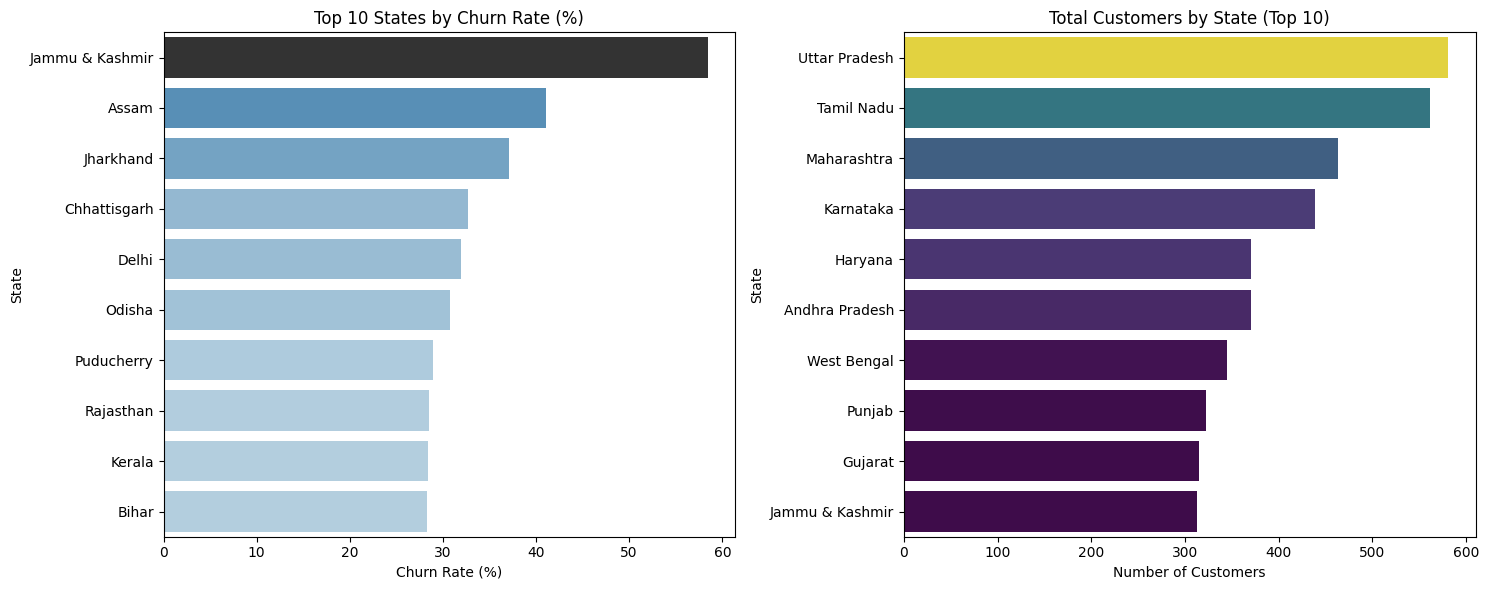

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 9. Top 10 states by churn rate
cr = churn_rate_by('State').head(10)
sns.barplot(x=cr.values, y=cr.index, ax=axes[0], palette='Blues_d', orient='h', hue=cr.values, legend=False)
axes[0].set_title('Top 10 States by Churn Rate (%)')
axes[0].set_xlabel('Churn Rate (%)')

# 10. Total customers by state (top 10)
top_states = df_churn['State'].value_counts().head(10)
sns.barplot(x=top_states.values, y=top_states.index, ax=axes[1], palette='viridis', orient='h', hue=cr.values, legend=False)
axes[1].set_title('Total Customers by State (Top 10)')
axes[1].set_xlabel('Number of Customers')

plt.tight_layout()
plt.show()

**Figure 4 — Services Used Insights**

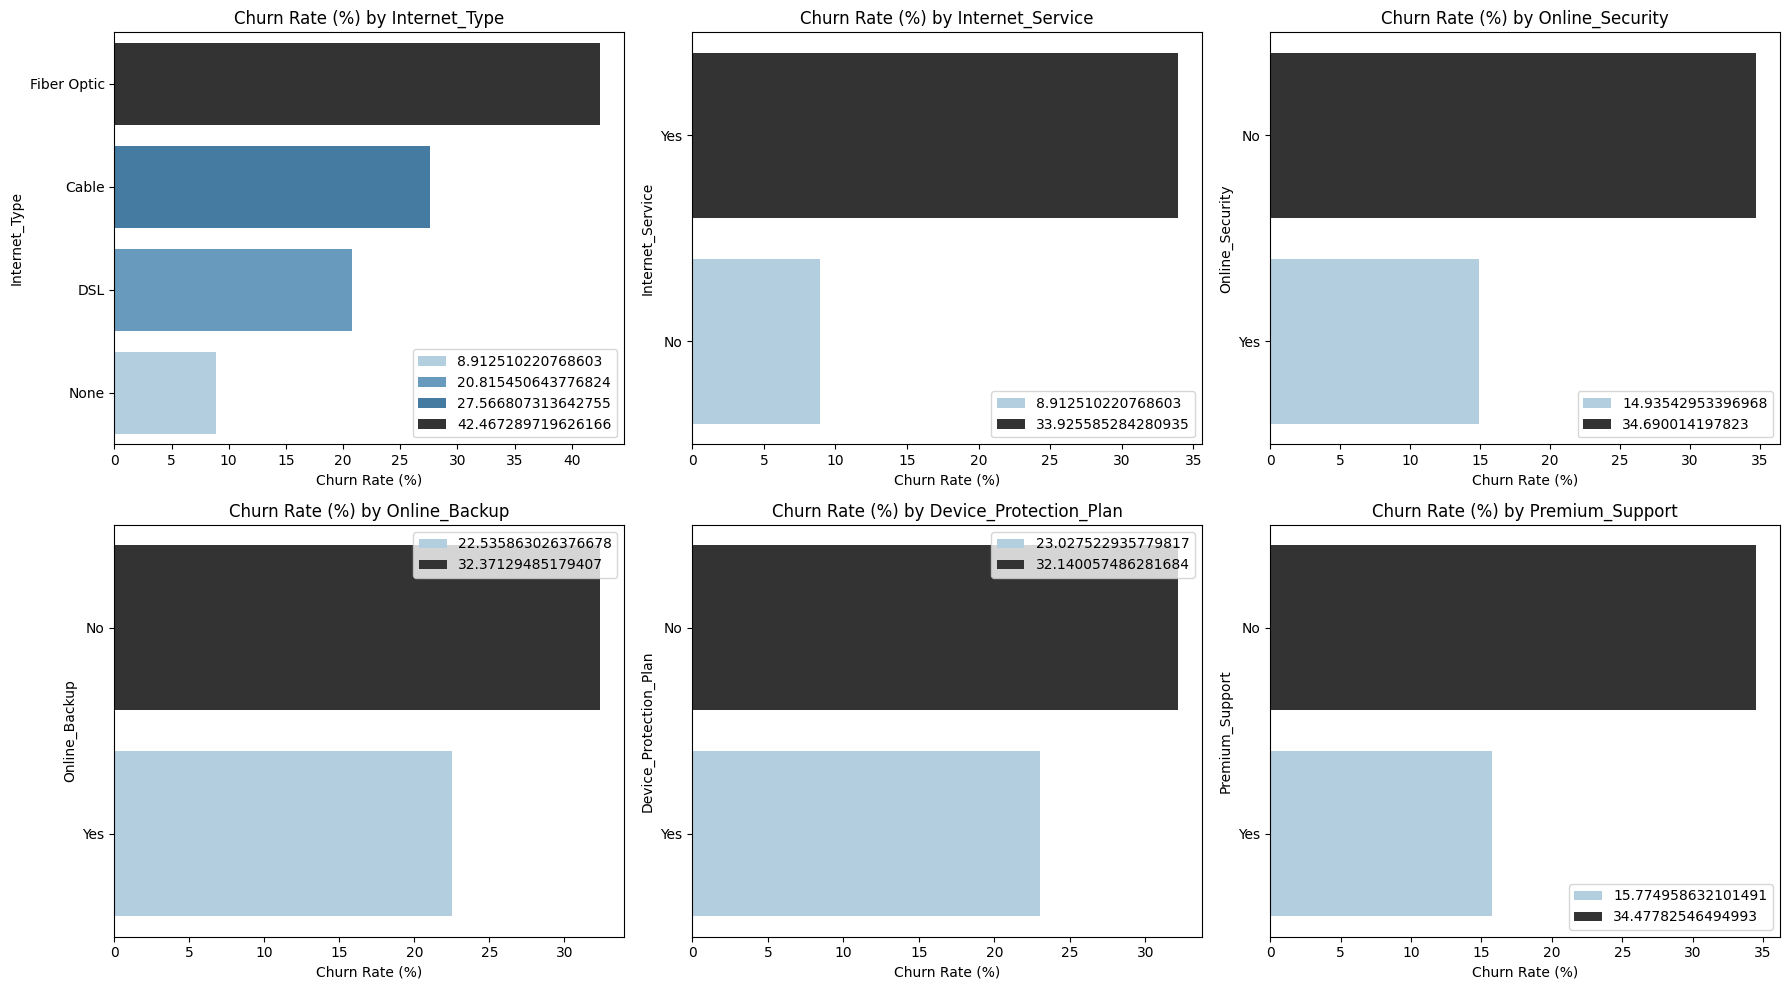

In [31]:
service_cols = ['Internet_Type', 'Internet_Service', 'Online_Security',
                 'Online_Backup', 'Device_Protection_Plan', 'Premium_Support']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    cr = churn_rate_by(col)
    sns.barplot(x=cr.values, y=cr.index, ax=axes[i], palette='Blues_d', orient='h', hue=cr.values)
    axes[i].set_title(f'Churn Rate (%) by {col}')
    axes[i].set_xlabel('Churn Rate (%)')

# 11-16 are axes[0] through axes[5] above

plt.tight_layout()
plt.show()

**Figure 5 — Churn Category Breakdown**

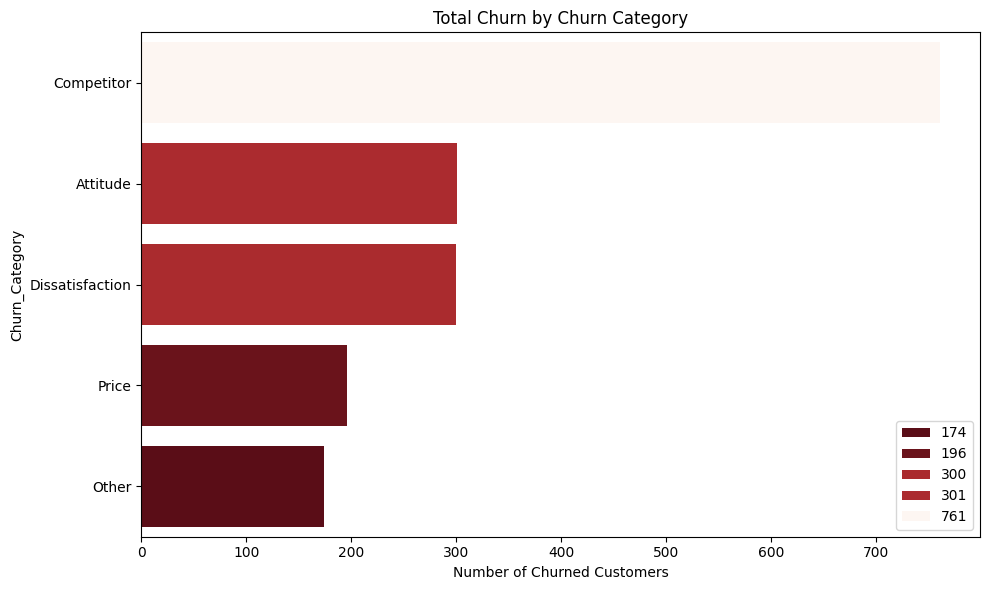

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

# 17. Distribution of churn reasons among churned customers only
cat_counts = df_churn[df_churn['Customer_Status'] == 'Churned']['Churn_Category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax, palette='Reds_r', orient='h', hue=cat_counts.values)
ax.set_title('Total Churn by Churn Category')
ax.set_xlabel('Number of Churned Customers')

plt.tight_layout()
plt.show()

**4. Feature Selection**

In [35]:
# Separate  features (X) and target variable (y)
# Drop the unneeded columns immediately to prevent target leakage
columns_to_drop = ["Churn_Category", "Churn_Reason", "Customer_ID","Customer_Status","Age_Group","Tenure_Group"]
X = df_churn.drop(columns=columns_to_drop, errors="ignore")

# Map the Target Variable string values to binary integers (Stayed = 0, Churned = 1)
y = df_churn["Customer_Status"].map({"Stayed": 0, "Churned": 1})

**5. Train-test splitting**

In [37]:
from sklearn.model_selection import train_test_split

# Performing the Train-Test Split
# Stratifying by 'y' ensures both sets have the same proportion of churned users
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (4805, 28)
Testing set shape: (1202, 28)


**6. Encoding categorical variables**

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Define column groups
nominal_cols = [
    "Gender",
    "Married",
    "State",
    "Value_Deal",
    "Phone_Service",
    "Multiple_Lines",
    "Internet_Service",
    "Internet_Type",
    "Online_Security",
    "Online_Backup",
    "Device_Protection_Plan",
    "Premium_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Streaming_Music",
    "Unlimited_Data",
    "Paperless_Billing",
    "Payment_Method",
]
ordinal_cols = ["Contract"]
contract_order = [["Month-to-Month", "One Year", "Two Year"]]

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=contract_order), ordinal_cols),
        ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_cols),
    ],
    remainder="passthrough",  # Keeps any remaining numerical columns untouched
)

# Configure the transformer to output clean Pandas DataFrames instead of NumPy arrays
preprocessor.set_output(transform="pandas")

# 4. Fit and Transform safely
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [40]:
X_train_processed

,ord__Contract,nom__Gender_Female,nom__Gender_Male,nom__Married_No,nom__Married_Yes,nom__State_Andhra Pradesh,nom__State_Assam,nom__State_Bihar,nom__State_Chhattisgarh,nom__State_Delhi,...,nom__Payment_Method_Mailed Check,remainder__Age,remainder__Number_of_Referrals,remainder__Tenure_in_Months,remainder__Monthly_Charge,remainder__Total_Charges,remainder__Total_Refunds,remainder__Total_Extra_Data_Charges,remainder__Total_Long_Distance_Charges,remainder__Total_Revenue
3800,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,21,0,9,20.05,552.90,0.00,0.0,467.10,1020.00
3187,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,66,3,17,53.55,53.55,0.00,0.0,1.59,55.14
4160,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,72,13,36,99.10,3877.95,0.00,0.0,356.07,4234.02
5222,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,67,9,31,116.50,6382.55,0.00,0.0,1611.50,7994.05
3426,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,79,7,21,69.60,131.65,0.00,0.0,30.64,162.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3163,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,76,12,24,19.95,214.75,0.00,0.0,324.94,539.69
4292,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,66,10,12,88.95,2291.20,0.00,0.0,1191.50,3482.70
220,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,32,13,4,86.85,6263.80,0.00,0.0,717.81,6981.61
3836,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,72,12,35,74.20,1133.90,43.31,0.0,352.95,1443.54


### Predictive Modeling & Model Selection

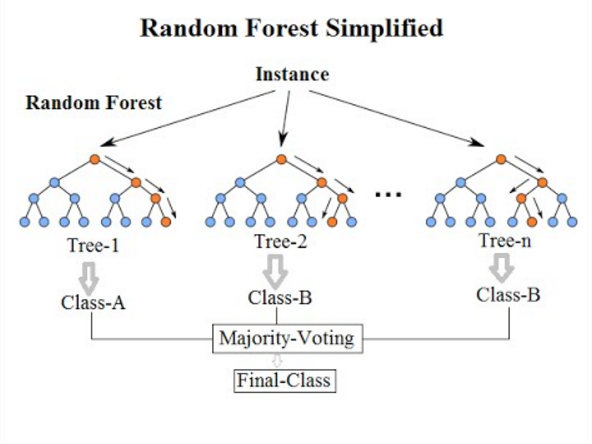
<b>Xgboost & LightGBM<b>
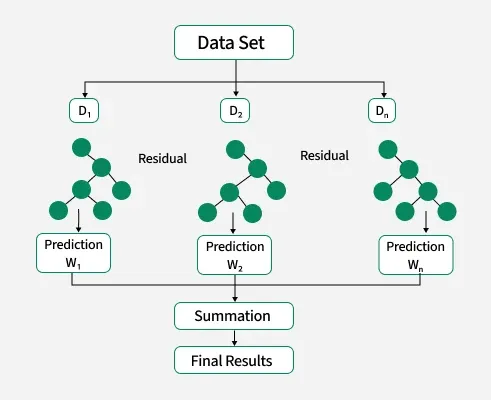

--- MODEL PERFORMANCE EVALUATION ---

================ Decision Tree ================
Accuracy  : 0.7887
Precision : 0.6084
Recall    : 0.7522
F1-Score  : 0.6727

================ Naive Bayes ================
Accuracy  : 0.7745
Precision : 0.5837
Recall    : 0.7637
F1-Score  : 0.6617

================ Random Forest ================
Accuracy  : 0.8378
Precision : 0.7123
Recall    : 0.7349
F1-Score  : 0.7234

================ XGBoost ================
Accuracy  : 0.8386
Precision : 0.7131
Recall    : 0.7378
F1-Score  : 0.7252

================ LightGBM ================
Accuracy  : 0.8228
Precision : 0.6642
Recall    : 0.7810
F1-Score  : 0.7179



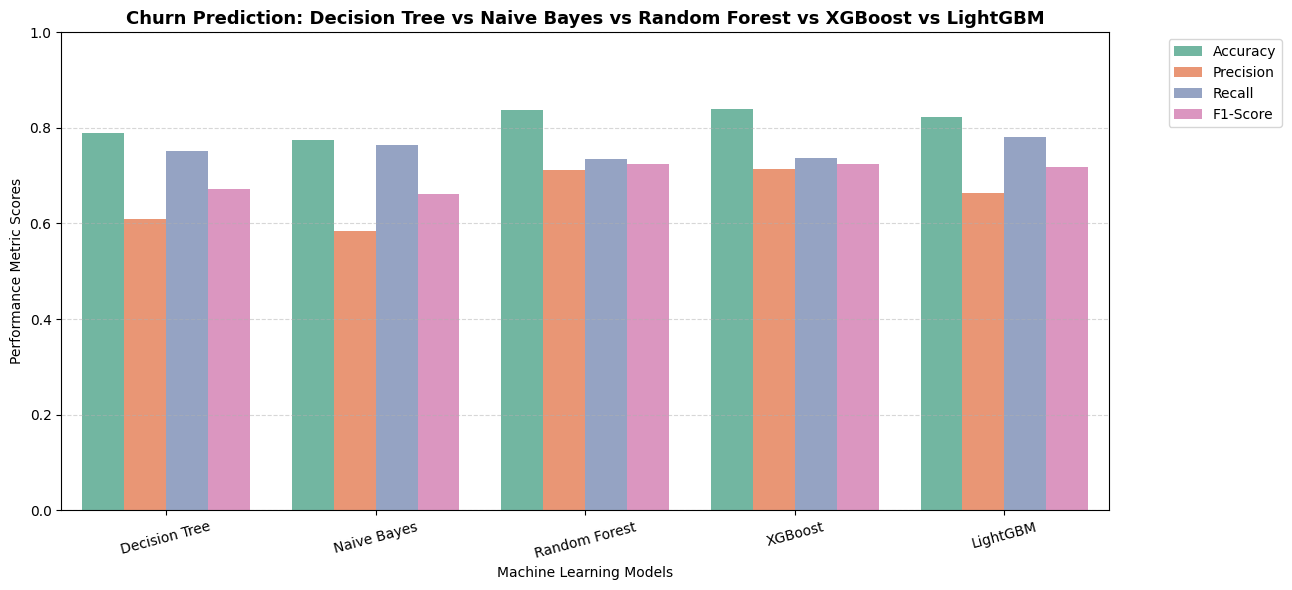

In [43]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier

# 1. Initialize all models to compare
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, random_state=42, class_weight="balanced"
    ),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=150, max_depth=10, random_state=42, class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=5,
        random_state=42,
        scale_pos_weight=2,
        eval_metric="logloss",
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=5,
        random_state=42,
        is_unbalance=True,  # Built-in handling for class imbalance
        verbose=-1,  # Suppress internal configuration warnings
    ),
}

# 2. Storage container for performance evaluation metrics
performance_metrics = []

# 3. Training and evaluation loop
print("--- MODEL PERFORMANCE EVALUATION ---\n")
for name, model in models.items():
    # Fit model on the processed training space
    model.fit(X_train_processed, y_train)

    # Generate predictions on test data
    y_pred = model.predict(X_test_processed)

    # Calculate operational metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Append metrics to final dataframe tracker
    performance_metrics.append(
        {
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
        }
    )

    # Print clean terminal report
    print(f"================ {name} ================")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}\n")

# 4. Transform collected metrics into a visualization DataFrame
metrics_df = pd.DataFrame(performance_metrics)
metrics_melted = pd.melt(
    metrics_df, id_vars="Model", var_name="Metric", value_name="Score"
)

# 5. Comparative visualization output
plt.figure(figsize=(13, 6))
sns.barplot(
    data=metrics_melted, x="Model", y="Score", hue="Metric", palette="Set2"
)
plt.title(
    "Churn Prediction: Decision Tree vs Naive Bayes vs Random Forest vs XGBoost vs LightGBM",
    fontsize=13,
    fontweight="bold",
)
plt.ylim(0, 1.0)
plt.ylabel("Performance Metric Scores")
plt.xlabel("Machine Learning Models")
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning (XGBoost)

Since XGBoost is a strong candidate for deployment, we search for improved hyperparameters using `RandomizedSearchCV`. Rather than optimizing for a single blended metric like F1-score, we use a custom scorer that maximizes **accuracy** while enforcing a **minimum recall floor of 70%** on the churn class. This ensures the search can't trade away the model's ability to catch at-risk customers just to inflate overall accuracy — any parameter combination that drops below the recall floor is penalized outright.

In [45]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer

# Custom scorer: reward accuracy, but only if recall stays above a business-acceptable floor
def accuracy_with_recall_floor(y_true, y_pred, min_recall=0.71):
    rec = recall_score(y_true, y_pred)
    if rec < min_recall:
        return rec - 1.0   # heavily penalize combos that fail the recall floor
    return accuracy_score(y_true, y_pred)

custom_scorer = make_scorer(accuracy_with_recall_floor)

# Wider, more targeted hyperparameter space for XGBoost
param_grid = {
    'n_estimators': [100, 150, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3],
    'scale_pos_weight': [1, 1.5, 2, 2.5, 3],
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=100,                # wider search than before
    scoring=custom_scorer,     # optimizes accuracy while enforcing recall >= 70%
    cv=cv_strategy,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train_processed, y_train)

print("Best Parameters:", random_search.best_params_)

tuned_model = random_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_processed)

print(f"\nTuned Model — Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Model — Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Model — Recall   : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Model — F1-Score : {f1_score(y_test, y_pred_tuned):.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'subsample': 0.6, 'scale_pos_weight': 2, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}

Tuned Model — Accuracy : 0.8461
Tuned Model — Precision: 0.7355
Tuned Model — Recall   : 0.7291
Tuned Model — F1-Score : 0.7323


### Final Model Selection & Business Strategy

Hyperparameter tuning was revisited using a recall-floor-constrained search (`RandomizedSearchCV` scored on accuracy subject to a minimum 70% recall), which produced a materially better trade-off than earlier attempts.

| Metric | Baseline XGBoost | Tuned XGBoost |
|---|---|---|
| Accuracy | 83.86% | **84.61%** |
| Precision | 71.31% | **73.55%** |
| Recall | **73.78%** | 72.91% |
| F1-Score | 72.52% | **73.23%** |

* **The Justification:** Unlike earlier tuning attempts (which traded away significant recall for accuracy — e.g. 65% recall for a similar accuracy gain), this tuned model gives up only **0.87 percentage points of recall** while improving **accuracy (+0.75 pp), precision (+2.24 pp), and F1-score (+0.71 pp)**.

* **Business Impact:** The recall gap is now small enough (roughly 1 additional missed churner per ~115 actual churners) that it no longer outweighs the gains elsewhere. The tuned model also produces meaningfully fewer false positives (higher precision), which translates directly into fewer wasted retention offers sent to customers who were never going to churn.

* **Decision:** The **Tuned XGBoost Model** is selected for deployment, replacing the baseline. It dominates on 3 of 4 metrics with only a negligible recall trade-off, making it the stronger overall choice for both retention coverage and operational efficiency.

In [47]:
import joblib

# 1. Baseline XGBoost model (kept for reference/comparison)
baseline_model = models["XGBoost"]

# 2. Tuned XGBoost model (selected for deployment)
final_model = tuned_model

# 3. Save the fitted preprocessor pipeline
joblib.dump(preprocessor, "churn_preprocessor.joblib")
print("Successfully saved: churn_preprocessor.joblib")

# 4. Save the baseline model (for reference)
joblib.dump(baseline_model, "baseline_xgb_model.joblib")
print("Successfully saved: baseline_xgb_model.joblib")

# 5. Save the tuned model (deployed model)
joblib.dump(final_model, "tuned_xgb_model.joblib")
print("Successfully saved: tuned_xgb_model.joblib")

Successfully saved: churn_preprocessor.joblib
Successfully saved: baseline_xgb_model.joblib
Successfully saved: tuned_xgb_model.joblib


### Confusion Matrix — Baseline XGBoost (Deployed Model)

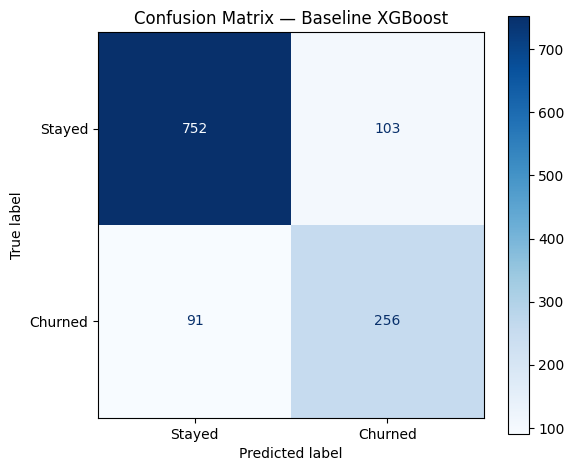

True Negatives  (correctly predicted Stayed) : 752
False Positives (predicted Churn, actually Stayed): 103
False Negatives (predicted Stayed, actually Churned): 91
True Positives  (correctly predicted Churned): 256


In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_baseline = baseline_model.predict(X_test_processed)
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=['Stayed', 'Churned'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — Baseline XGBoost')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_baseline.ravel()
print(f"True Negatives  (correctly predicted Stayed) : {tn}")
print(f"False Positives (predicted Churn, actually Stayed): {fp}")
print(f"False Negatives (predicted Stayed, actually Churned): {fn}")
print(f"True Positives  (correctly predicted Churned): {tp}")

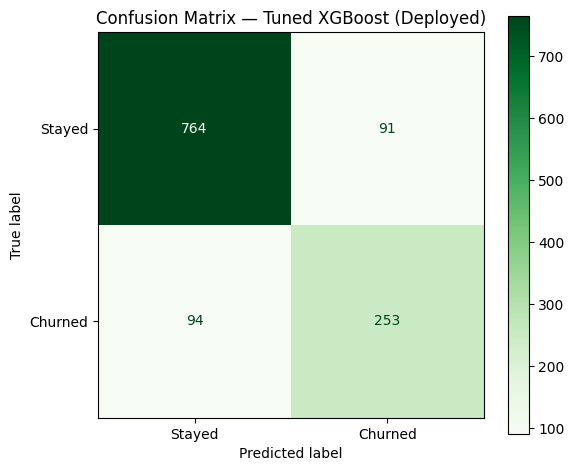

True Negatives  (correctly predicted Stayed) : 764
False Positives (predicted Churn, actually Stayed): 91
False Negatives (predicted Stayed, actually Churned): 94
True Positives  (correctly predicted Churned): 253


In [50]:
y_pred_tuned_final = final_model.predict(X_test_processed)
cm_tuned = confusion_matrix(y_test, y_pred_tuned_final)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Stayed', 'Churned'])
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title('Confusion Matrix — Tuned XGBoost (Deployed)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_tuned.ravel()
print(f"True Negatives  (correctly predicted Stayed) : {tn}")
print(f"False Positives (predicted Churn, actually Stayed): {fp}")
print(f"False Negatives (predicted Stayed, actually Churned): {fn}")
print(f"True Positives  (correctly predicted Churned): {tp}")

The matrix has actual labels on the rows and predicted labels on the columns:

- **Top-left (True Negative):** Customers who stayed and were correctly predicted to stay.
- **Top-right (False Positive):** Customers who stayed but were wrongly flagged as churn risks — the cost here is a wasted retention offer.
- **Bottom-left (False Negative):** Customers who churned but the model missed — this is the costliest error, since these are lost customers we never tried to retain.
- **Bottom-right (True Positive):** Customers who churned and were correctly caught by the model — these are the customers retention campaigns should target.

Because a missed churner (False Negative) is more expensive to the business than a false alarm (False Positive), this project prioritizes **Recall** over raw Accuracy when picking the final model — which is why the baseline XGBoost model (higher recall) was chosen over the higher-accuracy tuned version.

### Final Dataset Export for Dashboard Integration

1. Making predictions on a newly joined customers dataset
2. Filtering High-Risk Churn Profiles (Probability > 50%)
3. Serialization to CSV for PowerBI Dashboard

In [53]:
import joblib
import pandas as pd

# 1. Load saved production pipeline components
loaded_preprocessor = joblib.load("churn_preprocessor.joblib")
loaded_model = joblib.load("tuned_xgb_model.joblib")  # model is the tuned one

# 2. Extract features
columns_to_drop = [
    "Customer_ID",
    "Churn_Category",
    "Churn_Reason",
    "Customer_Status",
]
X_new = df_join.drop(columns=columns_to_drop, errors="ignore")

# 3. Transform the raw features using fitted transformer pipeline
X_new_processed = loaded_preprocessor.transform(X_new)

# 4. Generate the predictions and probabilities
df_join["Churn_Prediction"] = loaded_model.predict(X_new_processed)
df_join["Churn_Probability"] = loaded_model.predict_proba(X_new_processed)[:, 1]

# 5. Display the top at-risk customers sorted by highest probability
high_risk_customers = df_join[df_join["Churn_Prediction"] == 1].sort_values(
    by="Churn_Probability", ascending=False
)

print(f"Found {len(high_risk_customers)} customers at risk of churning.")
high_risk_customers.head()

Found 377 customers at risk of churning.


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason,Churn_Prediction,Churn_Probability
294,38920-PUN,Female,50,No,Punjab,8,7,None,Yes,No,...,43.85,0.0,10.0,15.90,69.75,Joined,Others,Others,1,0.995835
208,96967-CHH,Female,33,No,Chhattisgarh,5,8,None,Yes,No,...,89.35,0.0,0.0,5.36,94.71,Joined,Others,Others,1,0.995820
168,77137-MAH,Male,52,No,Maharashtra,1,8,Deal 5,Yes,No,...,45.55,0.0,0.0,16.34,61.89,Joined,Others,Others,1,0.995789
395,28782-PUN,Male,58,Yes,Punjab,8,7,Deal 5,Yes,No,...,44.95,0.0,0.0,13.63,58.58,Joined,Others,Others,1,0.995589
201,82170-TAM,Male,41,No,Tamil Nadu,5,29,None,Yes,No,...,44.60,0.0,0.0,45.28,89.88,Joined,Others,Others,1,0.995580


In [54]:
df_join.shape

(411, 34)

In [55]:
high_risk_customers.shape

(377, 34)

In [56]:
high_risk_customers.to_csv("high_risk_churn_list.csv", index=False)